In [ ]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
import cartopy
import cartopy.feature as cf
from google_crc32c import extend
from narwhals import col

# nc files provided by Ben Poschlod 04/05/2026

### Poschlod, B., Ludwig, R., and Sillmann, J.: Ten-year return levels of sub-daily extreme precipitation over Europe, Earth Syst. Sci. Data, 13, 983–1003, https://doi.org/10.5194/essd-13-983-2021, 2021

In [2]:
folder = "D:/EUROCORDEX_extremes/DATA/10yrRL_BenPosch/"

# Estimates of the 10-year return levels for EURADCLIM

### 1-hourly

C:\Users\eving\AppData\Local\Temp\ipykernel_7088\1119234399.py:18: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


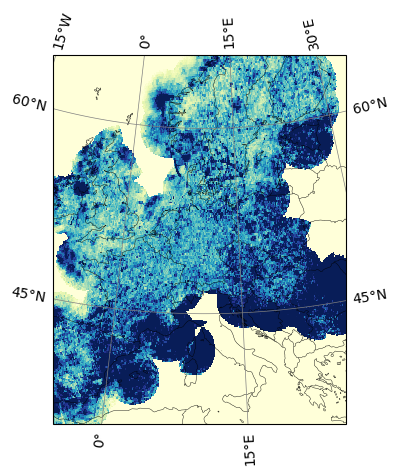

In [5]:
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)


# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

# loadtxt is fast for simple numeric files
fMod = "matrix_10yrRL_1hr_OBS_EURADCLIM_011EUi_2013-2022.csv"
RLMod = np.loadtxt(folder+fMod, delimiter=',')

folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
file_obs = f"OBS_EURADCLIM_011EUi_2013-2022_JJA_max_scale_S1.nc"
dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")

X = dsMod.lon.values
Y = dsMod.lat.values

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()
ax.set_extent([-5, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.3, color='black')
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,15), ylocs=range(-90,90,15),x_inline=False,y_inline=False)
ax.coastlines(resolution='50m', linewidth=0.3, color='black')
ax.pcolormesh(X, Y, RLMod, cmap="YlGnBu", vmin=3,vmax=30, transform=projorig)

### Daily return levels

C:\Users\eving\AppData\Local\Temp\ipykernel_10808\715103972.py:7: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")
c:\Users\eving\AppData\Local\miniconda3\envs\evalprecextremes\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


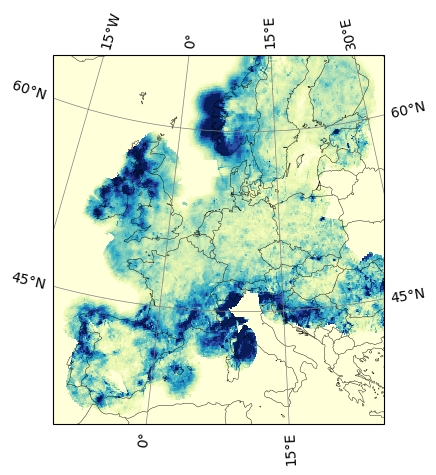

In [6]:
# loadtxt is fast for simple numeric files
fMod = "matrix_10yrRL_24hr_OBS_EURADCLIM_011EUi_2013-2022.csv"
RLMod = np.loadtxt(folder+fMod, delimiter=',')

folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
file_obs = f"OBS_EURADCLIM_011EUi_2013-2022_JJA_max_scale_S1.nc"
dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")

X = dsMod.lon.values
Y = dsMod.lat.values

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()
ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.3, color='black')
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,15), ylocs=range(-90,90,15),x_inline=False,y_inline=False)
ax.coastlines(resolution='50m', linewidth=0.3, color='black')
ax.pcolormesh(X, Y, RLMod, cmap="YlGnBu", vmin=40,vmax=210, transform=projorig)

# Reference return levels

# Compute lon/lat from rotated coordinates for the reference dataset

In [3]:
def unrot_lon(rlat, rlon, pole_lat, pole_lon):
    """
    Transform rotated longitude to regular non-rotated longitude lon(2D).
    """
    nrlat = np.shape(rlat)
    nrlon = np.shape(rlon)

    nrlat_rank = np.ndim(nrlat)
    nrlon_rank = np.ndim(nrlon)

    if(np.any(nrlat != nrlon) and (nrlat_rank != 1 or nrlon_rank != 1)):
        print("Function unrot_lon: rlat and rlon dimensions do not match")
        exit()

    if(nrlat_rank == 1 and nrlon_rank == 1):
        rlo = np.tile(rlon, (nrlat[0],1))
        rla = np.transpose([rlat]*nrlon[0])
    else:
        rla = rlat
        rlo = rlon

    rla = np.deg2rad(rla)
    rlo = np.deg2rad(rlo)

    s1 = np.sin(np.deg2rad(pole_lat))
    c1 = np.cos(np.deg2rad(pole_lat))
    s2 = np.sin(np.deg2rad(pole_lon))
    c2 = np.cos(np.deg2rad(pole_lon))

    tmp1 = s2*(-s1*np.cos(rlo)*np.cos(rla)+c1*np.sin(rla))-c2*np.sin(rlo)*np.cos(rla)
    tmp2 = c2*(-s1*np.cos(rlo)*np.cos(rla)+c1*np.sin(rla))+s2*np.sin(rlo)*np.cos(rla)

    lon = np.rad2deg(np.arctan(tmp1/tmp2))

    print('Function unrot_lon: min/max  %f / %f' % (np.min(lon[0,:]), np.max(lon[0,:])) )

    return lon

def unrot_lat(rlat, rlon, pole_lat, pole_lon):
    """
    Transform rotated latitude to regular non-rotated latitude lat(2D)
    """
    nrlat = np.shape(rlat)
    nrlon = np.shape(rlon)

    nrlat_rank = np.ndim(nrlat)
    nrlon_rank = np.ndim(nrlon)

    if(np.any(nrlat != nrlon) and (nrlat_rank != 1 or nrlon_rank != 1)):
        print("Function unrot_lat: rlat and rlon dimensions do not match")
        exit()

    if(nrlat_rank == 1 and nrlon_rank == 1):
        rlo = np.tile(rlon, (nrlat[0],1))
        rla = np.transpose([rlat]*nrlon[0])
    else:
        rla = rlat
        rlo = rlon

    rla = np.deg2rad(rla)
    rlo = np.deg2rad(rlo)

    s1 = np.sin(np.deg2rad(pole_lat))
    c1 = np.cos(np.deg2rad(pole_lat))

    lat = s1*np.sin(rla)+c1*np.cos(rla)*np.cos(rlo)
    lat = np.rad2deg(np.arcsin(lat))

    print('Function unrot_lat: min/max  %f / %f' % (np.min(lat[0,:]), np.max(lat[0,:])) )

    return lat

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


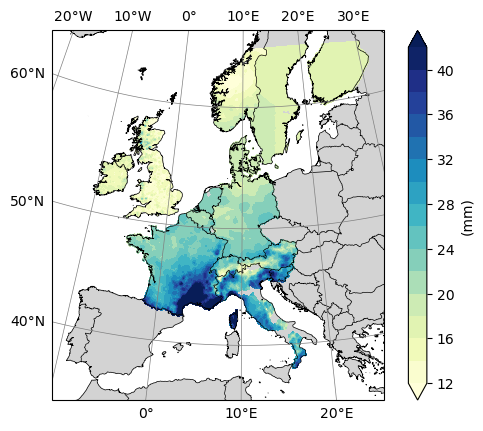

In [8]:
fObs = "return_levels_10a_1h.nc"
dsObs = xr.load_dataset(folder+fObs, engine="netcdf4")
var  = dsObs.return_levels_10a_1h
rlat = dsObs.rlat
rlon = dsObs.rlon
pole_lon = -162
pole_lat = 39.25

lon = unrot_lon(rlat, rlon, pole_lat, pole_lon)
lat = unrot_lat(rlat, rlon, pole_lat, pole_lon)

# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Graphic projection
projplot_name       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot_name].__call__(**projplot_dict)

ax = plt.axes(projection=projplot, transform = projorig)
ax.set_global()

ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
ax.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                linewidth=0.5, edgecolor='black')
gls = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
             x_inline=False,y_inline=False,rotate_labels = False)
gls.right_labels = False
p0 = ax.contourf(lon, lat, var, cmap="YlGnBu", levels=levels_1h, transform=projorig, extend = "both")

# Add fine resolution borders
# Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
fine_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='10m',
    facecolor='none'
)
ax.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

# Optional: Add coastlines at 10m
ax.coastlines(resolution='10m', linewidth=0.5)

plt.colorbar(p0, ax=ax, orientation='vertical', label='(mm)') 


In [ ]:
levels = {}
levels['1h'] = np.linspace(12, 42, 16)
levels['3h'] = np.linspace(20, 60, 11)
levels['6h'] = np.linspace(30, 80, 11)
levels['12h'] = np.linspace(30, 110, 17)
levels['24h'] = np.linspace(40, 210, 18)

for agg in ["1h", "3h", "6h", "12h", "24h"]:

    levels_plot = levels[agg]

    fig = plt.figure(figsize=(10, 6))


    #######################################################################################
    # Reference 10-year return levels
    #######################################################################################

    fObs = "return_levels_10a_"+agg+".nc"
    dsObs = xr.load_dataset(folder+fObs, engine="netcdf4")
    var  = dsObs["return_levels_10a_"+agg]

    rlat = dsObs.rlat
    rlon = dsObs.rlon
    pole_lon = -162
    pole_lat = 39.25

    lon = unrot_lon(rlat, rlon, pole_lat, pole_lon)
    lat = unrot_lat(rlat, rlon, pole_lat, pole_lon)

    ax = fig.add_subplot(1, 3, 1,projection=projplot, transform = projorig)
    ax.set_global()
    ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
    ax.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                    linewidth=0.5, edgecolor='black')
    gls = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
                x_inline=False,y_inline=False,rotate_labels = False)
    gls.right_labels = False
    p0=ax.contourf(lon, lat, var, levels=levels_plot, cmap="YlGnBu", transform=projorig, extend = "both")

    # Add fine resolution borders
    # Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
    fine_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none'
    )
    ax.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

    # Optional: Add coastlines at 10m
    ax.coastlines(resolution='10m', linewidth=0.5)

    plt.colorbar(p0, ax=ax, orientation='vertical', label='(mm)',shrink=0.5)


    #######################################################################################
    # EURADCLIM 10-year return levels
    #######################################################################################
    # loadtxt is fast for simple numeric files
    fMod = "matrix_10yrRL_"+agg+"r_OBS_EURADCLIM_011EUi_2013-2022.csv"
    var = np.loadtxt(folder+fMod, delimiter=',')

    folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
    file_obs = f"OBS_EURADCLIM_011EUi_2013-2022_JJA_max_scale_S1.nc"
    dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")

    lon = dsMod.lon.values
    lat = dsMod.lat.values

    ax2 = fig.add_subplot(1, 3, 2,projection=projplot, transform = projorig)
    ax2.set_global()
    ax2.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
    ax2.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
    ax2.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                    linewidth=0.5, edgecolor='black')
    gls = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
                x_inline=False,y_inline=False,rotate_labels = False)
    gls.right_labels = False
    p0=ax2.contourf(lon, lat, var, levels=levels_plot, cmap="YlGnBu", transform=projorig, extend = "both")

    # Add fine resolution borders
    # Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
    fine_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none'
    )
    ax2.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

    # Optional: Add coastlines at 10m
    ax2.coastlines(resolution='10m', linewidth=0.5)

    plt.colorbar(p0, ax=ax2, orientation='vertical', label='(mm)',shrink=0.5)


    # save the figure
    plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL10/10yrRL_{agg}_diffEURAD.png', dpi=300, bbox_inches='tight')
    plt.close()

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2898973410.py:67: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2898973410.py:67: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


In [11]:
levels_plot = levels["24h"]

fig = plt.figure(figsize=(10, 40))

for iagg, agg in enumerate(["1h", "3h", "6h", "12h", "24h"]):

    #######################################################################################
    # Reference 10-year return levels
    #######################################################################################

    fObs = "return_levels_10a_"+agg+".nc"
    dsObs = xr.load_dataset(folder+fObs, engine="netcdf4")
    var  = dsObs["return_levels_10a_"+agg]

    rlat = dsObs.rlat
    rlon = dsObs.rlon
    pole_lon = -162
    pole_lat = 39.25

    lon = unrot_lon(rlat, rlon, pole_lat, pole_lon)
    lat = unrot_lat(rlat, rlon, pole_lat, pole_lon)

    ax = fig.add_subplot(5, 2, iagg*2+1, projection=projplot, transform = projorig)
    ax.set_global()
    ax.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
    ax.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                    linewidth=0.5, edgecolor='black')
    gls = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
                x_inline=False,y_inline=False,rotate_labels = False)
    gls.right_labels = False
    p0=ax.contourf(lon, lat, var, levels=levels_plot, cmap="YlGnBu", transform=projorig, extend = "both")

    # Add fine resolution borders
    # Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
    fine_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none'
    )
    ax.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

    # Optional: Add coastlines at 10m
    ax.coastlines(resolution='10m', linewidth=0.5)

    plt.colorbar(p0, ax=ax, orientation='vertical', label='(mm)',shrink=0.5)


    #######################################################################################
    # EURADCLIM 10-year return levels
    #######################################################################################
    # loadtxt is fast for simple numeric files
    fMod = "matrix_10yrRL_"+agg+"r_OBS_EURADCLIM_011EUi_2013-2022.csv"
    var = np.loadtxt(folder+fMod, delimiter=',')

    folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'
    file_obs = f"OBS_EURADCLIM_011EUi_2013-2022_JJA_max_scale_S1.nc"
    dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")

    lon = dsMod.lon.values
    lat = dsMod.lat.values

    ax2 = fig.add_subplot(5, 2, iagg*2+2,projection=projplot, transform = projorig)
    ax2.set_global()
    ax2.set_extent([-10, 25, 35, 65], crs=ccrs.PlateCarree())
    ax2.add_feature(cartopy.feature.OCEAN, color='white', zorder=0)
    ax2.add_feature(cartopy.feature.LAND, color='lightgray',zorder=0,
                    linewidth=0.5, edgecolor='black')
    gls = ax2.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,10), ylocs=range(-90,90,10),
                x_inline=False,y_inline=False,rotate_labels = False)
    gls.right_labels = False
    p0=ax2.contourf(lon, lat, var, levels=levels_plot, cmap="YlGnBu", transform=projorig, extend = "both")

    # Add fine resolution borders
    # Category: 'cultural', Name: 'admin_0_boundary_lines_land', Scale: '10m'
    fine_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none'
    )
    ax2.add_feature(fine_borders, edgecolor='black', linewidth=0.5)

    # Optional: Add coastlines at 10m
    ax2.coastlines(resolution='10m', linewidth=0.5)

    plt.colorbar(p0, ax=ax2, orientation='vertical', label='(mm)',shrink=0.5)

# save the figure
plt.savefig(f'D:/EUROCORDEX_extremes/FIGURES/DIFF_RL10/10yrRL_samescale_diffEURAD.png', dpi=300, bbox_inches='tight')
plt.close()

Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2359463653.py:59: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2359463653.py:59: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2359463653.py:59: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2359463653.py:59: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


Function unrot_lon: min/max  -6.200426 / 28.357166
Function unrot_lat: min/max  30.427963 / 33.975002


C:\Users\eving\AppData\Local\Temp\ipykernel_7088\2359463653.py:59: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dsMod = xr.load_dataset(folder_obs+file_obs, engine="netcdf4")


In [9]:
(iagg+1,2)

(2, 2)